# One-dimensional linear OT PCA

This notebook generates `fig:linear-ot-1d-pca`.  In one dimension, the quadratic Wasserstein geometry is exactly linearized by quantile functions: a probability density \(\alpha\) is represented by

$$
    Q_\alpha(u) = F_\alpha^{-1}(u), \qquad u\in(0,1),
$$

and \(\mathcal W_2^2(\alpha,\beta)=\int_0^1 |Q_\alpha(u)-Q_\beta(u)|^2\,du\).  We build a synthetic dataset of two-Gaussian mixtures with varying locations and scales, compute PCA in the Hilbert space \(L^2(0,1)\), and convert excursions along the leading quantile directions back into densities for display.


In [1]:
from pathlib import Path
import os
import sys
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

from figure_style import BLUE, GRAY, RED, VIOLET, box_axes, figure_dir, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "linear-ot-1d-pca"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(203911)


## Synthetic two-Gaussian mixtures

Each training measure is a mixture of two Gaussian bumps.  A few low-dimensional latent variables control global translation, separation of the two components, and component-wise scales.  The displayed curves are ordinary densities, but the PCA is performed on finely sampled quantile functions.


In [2]:
def gaussian_pdf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def normalize_density(x, rho):
    rho = np.maximum(rho, 0.0)
    mass = np.trapz(rho, x)
    return rho / max(mass, 1e-15)


def quantile_from_density(x, rho, u):
    dx = np.diff(x)
    cdf = np.empty_like(x)
    cdf[0] = 0.0
    cdf[1:] = np.cumsum(0.5 * (rho[:-1] + rho[1:]) * dx)
    cdf = cdf / max(cdf[-1], 1e-15)
    cdf = np.maximum.accumulate(cdf)
    cdf[-1] = 1.0
    return np.interp(u, cdf, x)


def density_from_quantile(q, u, x, *, smooth=34.0):
    # Since q=F^{-1}, the density at q(u) is 1/q'(u).
    # The quantile is smoothed before differentiation only for display, to
    # avoid amplifying interpolation noise in very low-density valleys.
    q = np.maximum.accumulate(q)
    q_smooth = gaussian_filter1d(q, sigma=24.0, mode="nearest")
    q_smooth = np.maximum.accumulate(q_smooth)
    dq = np.gradient(q_smooth, u)
    dq = gaussian_filter1d(dq, sigma=34.0, mode="nearest")
    dq = np.maximum(dq, 2e-4)
    values = 1.0 / dq
    order = np.argsort(q_smooth)
    rho = np.interp(x, q_smooth[order], values[order], left=0.0, right=0.0)
    rho = gaussian_filter1d(rho, sigma=smooth, mode="nearest")
    return normalize_density(x, rho)


x = np.linspace(-4.2, 4.2, 5200)
u = np.linspace(3e-5, 1 - 3e-5, 7200)
N = 110
latent = rng.normal(size=(N, 5))

# Correlated variations make the principal directions interpretable.
center = 0.30 * latent[:, 0]
separation = 2.05 + 0.42 * latent[:, 1]
separation = np.clip(separation, 1.30, 2.85)
global_scale = np.exp(0.18 * latent[:, 2])
scale_skew = latent[:, 3]
weight_skew = 0.09 * np.tanh(0.85 * latent[:, 4] - 0.25 * latent[:, 1])

means_left = center - 0.5 * separation + 0.06 * rng.normal(size=N)
means_right = center + 0.5 * separation + 0.06 * rng.normal(size=N)
sigmas_left = 0.18 * global_scale * np.exp(0.28 * scale_skew + 0.04 * rng.normal(size=N))
sigmas_right = 0.24 * global_scale * np.exp(-0.24 * scale_skew + 0.04 * rng.normal(size=N))
weights_left = np.clip(0.50 + weight_skew, 0.34, 0.66)

params = []
densities = []
quantiles = []
for wl, ml, mr, sl, sr in zip(weights_left, means_left, means_right, sigmas_left, sigmas_right):
    rho = wl * gaussian_pdf(x, ml, sl) + (1 - wl) * gaussian_pdf(x, mr, sr)
    rho = normalize_density(x, rho)
    densities.append(rho)
    quantiles.append(quantile_from_density(x, rho, u))
    params.append((wl, ml, mr, sl, sr))

densities = np.asarray(densities)
quantiles = np.asarray(quantiles)
print(f"dataset: {N} two-Gaussian mixtures")
print(f"quantile grid: {len(u)} points, density grid: {len(x)} points")


dataset: 110 two-Gaussian mixtures
quantile grid: 7200 points, density grid: 5200 points


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_98453/3251169954.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = np.trapz(rho, x)


## PCA in quantile coordinates

The quadrature weights approximate the \(L^2(0,1)\) inner product.  If \(\bar Q\) is the empirical mean quantile and \(e_k\) is a unit principal direction, the displayed excursions are

$$
    Q_{k,a}(u)=\bar Q(u)+a e_k(u), \qquad a\in[-A_k,A_k].
$$

The amplitudes \(A_k\) are chosen large enough to show visible deformations and small enough to keep the quantile functions increasing. For display, the densities are reconstructed from the relation \(ho(Q(u))=1/Q'(u)\), with a mild smoothing of the quantile derivative to suppress numerical artifacts in very low-density valleys.


In [3]:
du = np.empty_like(u)
du[1:-1] = 0.5 * (u[2:] - u[:-2])
du[0] = u[1] - u[0]
du[-1] = u[-1] - u[-2]
du = du / du.sum()

Qbar = quantiles.mean(axis=0)
X = (quantiles - Qbar) * np.sqrt(du)[None, :]
U, S, Vt = np.linalg.svd(X, full_matrices=False)
explained = S**2 / (N - 1)
modes = Vt[:3] / np.sqrt(du)[None, :]
mode_std = np.sqrt(explained[:3])


def admissible_amplitude(mode, target):
    amp = 2.45 * target
    for _ in range(32):
        ok = True
        for a in (-amp, amp):
            q = Qbar + a * mode
            if np.min(np.diff(q)) <= 2e-5:
                ok = False
                break
        if ok:
            return amp
        amp *= 0.88
    return amp

amplitudes = np.array([admissible_amplitude(modes[k], mode_std[k]) for k in range(3)])
mean_density = density_from_quantile(Qbar, u, x, smooth=1.05)
print("explained variance ratio:", np.round(explained[:5] / explained.sum(), 3))
print("mode amplitudes:", np.round(amplitudes, 3))


explained variance ratio: [0.537 0.232 0.128 0.039 0.021]
mode amplitudes: [0.148 0.097 0.064]


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_98453/3251169954.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = np.trapz(rho, x)


## Rendering panels

The dataset panel shows representative training densities and their Wasserstein barycenter, obtained by averaging quantiles.  Each mode panel overlays density snapshots along a single quantile-PCA direction, with red-to-blue colors encoding increasing coefficient \(a\).


In [4]:
def finish_density_axis(ax, ymax=None):
    ax.set_xlim(-3.25, 3.25)
    if ymax is not None:
        ax.set_ylim(0, ymax)
    ax.tick_params(labelbottom=False, labelleft=False)
    box_axes(ax)


def plot_density_curve(ax, rho, color, *, lw=1.0, alpha=1.0, fill=False, zorder=2):
    if fill:
        ax.fill_between(x, 0, rho, color=color, alpha=0.075 * alpha, linewidth=0, zorder=zorder - 1)
    ax.plot(x, rho, color=color, lw=lw, alpha=alpha, zorder=zorder)


# Pick examples spanning the first two PCA scores, not merely random curves.
scores = X @ Vt[:3].T
angles = np.arctan2(scores[:, 1], scores[:, 0])
chosen = []
for theta in np.linspace(-np.pi, np.pi, 12, endpoint=False):
    score = np.cos(angles - theta) * np.linalg.norm(scores[:, :2], axis=1)
    idx = int(np.argmax(score))
    if idx not in chosen:
        chosen.append(idx)
while len(chosen) < 12:
    idx = int(rng.integers(0, N))
    if idx not in chosen:
        chosen.append(idx)

# Dataset examples.
fig, ax = plt.subplots(figsize=(3.15, 1.72))
for j, idx in enumerate(chosen):
    color = interp_color(j / max(len(chosen) - 1, 1))
    plot_density_curve(ax, densities[idx], color, lw=0.82, alpha=0.60, fill=False, zorder=2)
plot_density_curve(ax, mean_density, VIOLET, lw=1.35, alpha=0.96, fill=False, zorder=5)
finish_density_axis(ax, ymax=2.35)
save_pdf(fig, OUT / "dataset.pdf", pad_inches=0.045)
plt.close(fig)

mode_densities = []
for k in range(3):
    coeffs = np.linspace(-amplitudes[k], amplitudes[k], 8)
    panel = []
    for a in coeffs:
        q = Qbar + a * modes[k]
        panel.append(density_from_quantile(q, u, x))
    mode_densities.append(np.asarray(panel))
    fig, ax = plt.subplots(figsize=(3.15, 1.72))
    for j, rho in enumerate(panel):
        color = interp_color(j / (len(panel) - 1))
        plot_density_curve(ax, rho, color, lw=1.00, alpha=0.92, fill=True, zorder=2 + j)
    finish_density_axis(ax, ymax=max(2.45, 1.08 * np.max(panel)))
    save_pdf(fig, OUT / f"mode-{k+1}.pdf", pad_inches=0.045)
    plt.close(fig)


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_98453/3251169954.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = np.trapz(rho, x)


In [5]:
# Thumbnail/contact sheet for the notebook gallery.
fig, axes = plt.subplots(2, 2, figsize=(6.6, 3.55))
axes = axes.ravel()
for j, idx in enumerate(chosen[:10]):
    axes[0].plot(x, densities[idx], color=interp_color(j / 9), lw=0.78, alpha=0.58)
axes[0].plot(x, mean_density, color=VIOLET, lw=1.28)
for k in range(3):
    ax = axes[k + 1]
    panel = mode_densities[k]
    for j, rho in enumerate(panel):
        ax.fill_between(x, 0, rho, color=interp_color(j / (len(panel) - 1)), alpha=0.055, linewidth=0)
        ax.plot(x, rho, color=interp_color(j / (len(panel) - 1)), lw=0.92, alpha=0.92)
for ax in axes:
    finish_density_axis(ax, ymax=None)
fig.subplots_adjust(wspace=0.12, hspace=0.22)
fig.savefig(THUMB, dpi=170, bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

for pdf in OUT.glob("*.pdf"):
    shutil.copy2(pdf, ARXIV_OUT / f"{NAME}--{pdf.name}")

print(f"wrote {OUT}")
print(f"thumbnail: {THUMB}")


wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/linear-ot-1d-pca
thumbnail: /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/linear-ot-1d-pca.png


## Visual check

The notebook exports separate PDF panels for LaTeX and a compact PNG thumbnail for the searchable gallery.


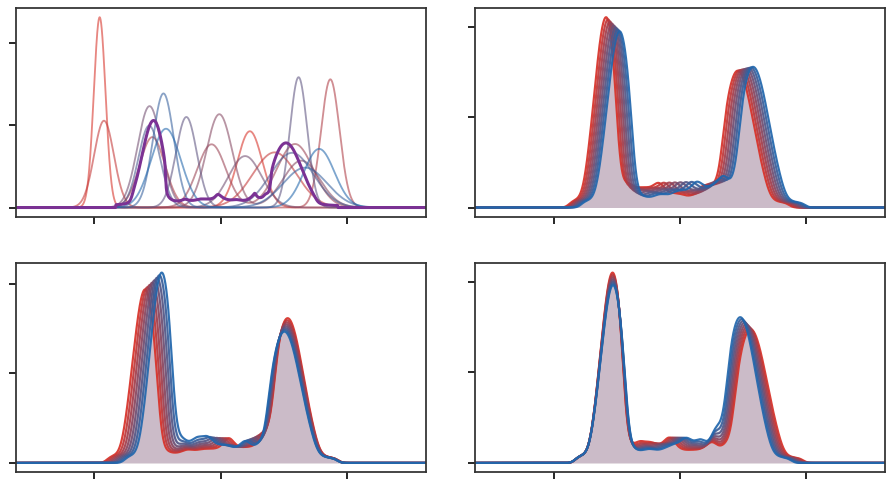

In [6]:
from IPython.display import Image, display

display(Image(filename=str(THUMB)))
